# Lake Coldwater Habitat — Data Overview

This notebook is a Python companion to an R-based research project modeling
**coldwater fish habitat** in five North Temperate Lakes (NTL-LTER, Wisconsin):
Allequash (AL), Big Muskellunge (BM), Crystal (CR), Sparkling (SP), and Trout (TR).

**CVHT** (cumulative volumetric habitat thickness) is the outcome variable: the
depth range in a lake where temperature ≤ 17°C *and* dissolved oxygen ≥ 3 mg/L —
the coldwater refuge zone fish can occupy — averaged monthly and summed across
July–August–September (JAS) for each lake-year. Predictors mix large-scale
climate indices (ENSO/MEI, wind, geopotential height) with local limnology
(water temperature, nutrients, chlorophyll, lake level, ice duration).

This notebook loads the master modeling table and looks at how CVHT has moved
over time, lake by lake.


In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio

from src.data import load_master_table, LAKE_NAMES, OUTCOME_COL
from src.viz import set_style, LAKE_COLORS

set_style()
# Committed notebooks embed a static PNG snapshot of every Plotly figure so they
# render on GitHub; reopen locally and set this to "notebook" or "browser" for
# full interactivity (hover, zoom, pan).
pio.renderers.default = "png"

df = load_master_table()
df.head()


,lakeid,Year,CVHT_standardized,n_months_sampled,mei,nino4,oni,sstcorr1,sstcorr2,zonalwind500,...,surfacezonalwind,surfacemomentumflux,air_temp,water_temp,phosphorus,nitrogen,chlorophyll,lake_level,ice_on_duration,lake_name
0,AL,1981,0.0,2,-0.7,28.235,-0.37,28.405,22.307,17.011,...,0.762,-44.613,4.600000,16.30,17.619048,269.12381,5.38378,494.150397,147.219512,Allequash
1,AL,1982,6.0,3,0.6,29.130,0.47,29.361,22.565,10.842,...,0.262,-20.681,3.496739,16.55,17.619048,269.12381,11.17500,494.150397,149.000000,Allequash
2,AL,1983,3.5,3,2.0,28.875,1.29,28.690,22.019,8.651,...,0.168,-15.680,2.939130,12.20,17.619048,269.12381,8.30000,494.150397,160.000000,Allequash
3,AL,1984,3.5,3,-0.7,27.940,-0.43,28.061,21.955,11.138,...,1.242,-89.082,2.908696,12.00,17.619048,269.12381,8.92500,494.450000,150.000000,Allequash
4,AL,1985,7.5,3,-0.7,27.705,-0.78,28.115,22.382,14.206,...,0.985,-84.256,5.821739,16.90,17.619048,269.12381,7.97500,494.325000,163.000000,Allequash


## Coverage: how many lake-years do we have?

In [2]:
coverage = (
    df.groupby("lake_name")["Year"]
    .agg(first_year="min", last_year="max", n_years="count")
    .sort_values("first_year")
)
coverage


,first_year,last_year,n_years
lake_name,,,
Allequash,1981,2024,44
Big Muskellunge,1981,2024,44
Crystal,1981,2024,44
Sparkling,1981,2024,44
Trout,1981,2024,44


## CVHT over time, by lake

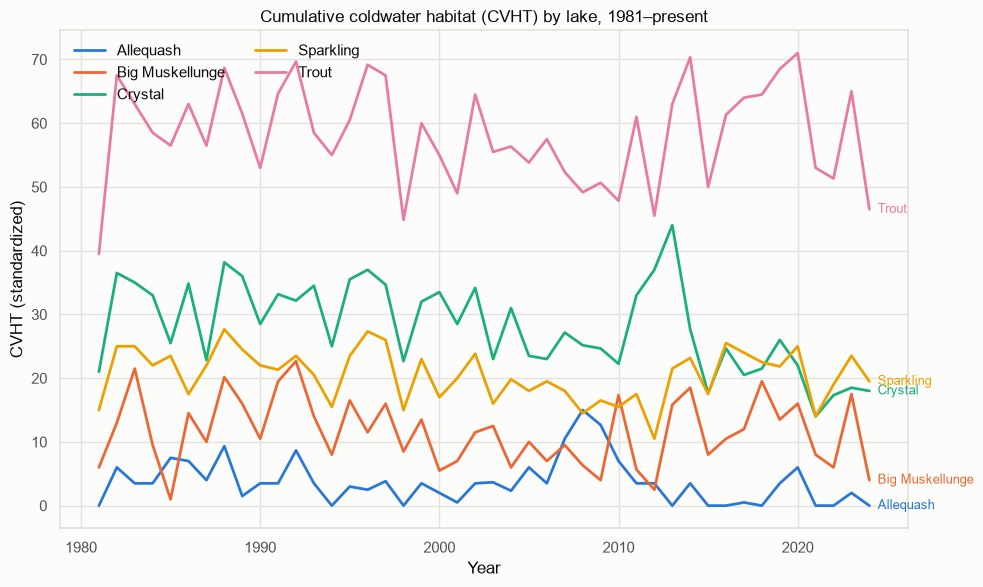

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
for lake_id, g in df.groupby("lakeid", sort=False):
    g = g.sort_values("Year")
    ax.plot(g["Year"], g[OUTCOME_COL], color=LAKE_COLORS[lake_id], linewidth=2, label=LAKE_NAMES[lake_id])
    ax.annotate(
        LAKE_NAMES[lake_id],
        xy=(g["Year"].iloc[-1], g[OUTCOME_COL].iloc[-1]),
        xytext=(6, 0),
        textcoords="offset points",
        color=LAKE_COLORS[lake_id],
        fontsize=9,
        va="center",
    )
ax.set_xlabel("Year")
ax.set_ylabel("CVHT (standardized)")
ax.set_title("Cumulative coldwater habitat (CVHT) by lake, 1981–present")
ax.legend(loc="upper left", ncol=2, frameon=False)
fig.tight_layout()
fig.savefig("../figures/01_cvht_timeseries.png", dpi=150)
plt.show()


Interactive version — hover a point to see the exact lake-year value.

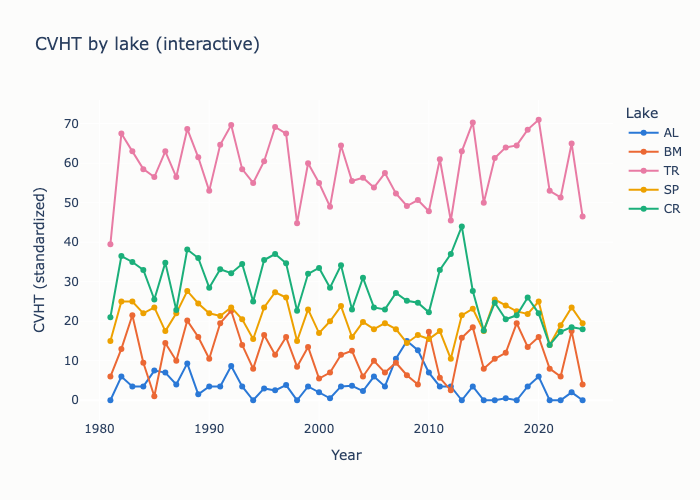

In [4]:
fig = px.line(
    df.sort_values("Year"),
    x="Year",
    y=OUTCOME_COL,
    color="lakeid",
    color_discrete_map=LAKE_COLORS,
    labels={OUTCOME_COL: "CVHT (standardized)", "lakeid": "Lake"},
    title="CVHT by lake (interactive)",
    markers=True,
)
fig.update_layout(plot_bgcolor="#fcfcfb", paper_bgcolor="#fcfcfb")
fig.show()


## Distribution of CVHT by lake

Some lakes run consistently warmer/shallower-refuge than others.

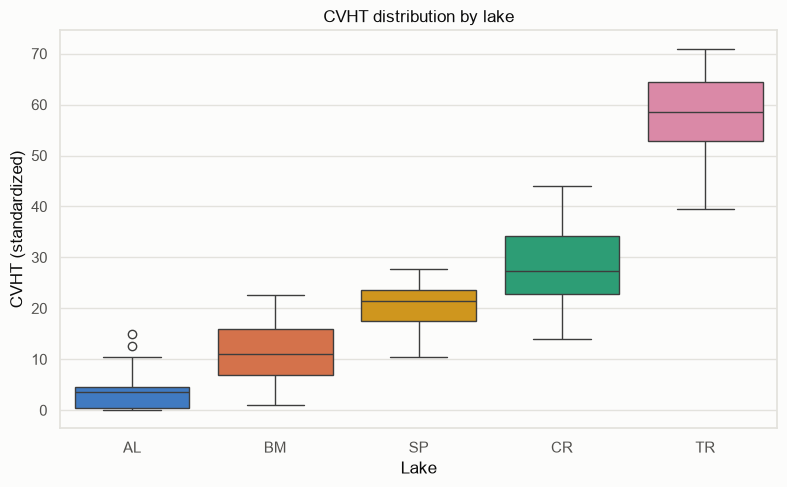

In [5]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 5))
order = df.groupby("lakeid")[OUTCOME_COL].median().sort_values().index
sns.boxplot(
    data=df, x="lakeid", y=OUTCOME_COL, order=order, hue="lakeid",
    palette=LAKE_COLORS, legend=False, ax=ax,
)
ax.set_xlabel("Lake")
ax.set_ylabel("CVHT (standardized)")
ax.set_title("CVHT distribution by lake")
fig.tight_layout()
fig.savefig("../figures/01_cvht_distribution.png", dpi=150)
plt.show()
